In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
df = pd.read_csv(f"{PROJECT_ROOT}/data/dataset.csv")
df.head()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
0,23.865083,56.660004,5.737366,0.448821,13.583201,0.412864,0.395673,0.127440,0.334763,0.990240,1
1,15.755624,67.562554,3.761696,0.203759,9.119581,0.343221,0.877234,0.197382,0.688851,0.663392,0
2,14.719641,60.782993,3.558324,0.259485,6.966499,0.336209,0.455082,0.196271,0.279968,0.905470,0
3,14.719814,72.431960,0.560680,0.210146,4.188474,0.277365,0.730398,0.090561,0.643183,0.891052,0
4,43.372854,33.125925,12.071894,0.685767,9.363837,0.643574,0.210252,0.140736,0.957246,0.944823,1


In [8]:
df.describe()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,label
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,20.116392,55.895658,6.351934,0.335010,7.959204,0.401409,0.560445,0.150426,0.497673,0.699993,0.450000
std,12.604460,16.584939,4.384556,0.209370,5.666685,0.135858,0.182694,0.078367,0.289784,0.172762,0.497556
min,0.326223,5.000000,0.002577,0.000000,0.109818,0.124681,0.000000,0.000000,0.000094,0.400063,0.000000
25%,10.933062,46.412276,2.939375,0.181017,3.922624,0.303003,0.453835,0.094160,0.241122,0.549426,0.000000
50%,17.535134,57.994579,5.780743,0.297576,6.521932,0.378663,0.576044,0.148212,0.495915,0.701816,0.000000
75%,26.604050,67.643562,8.810003,0.453174,10.463889,0.475957,0.691486,0.202875,0.752959,0.845197,1.000000
max,116.858197,90.000000,37.937951,1.000000,43.285818,1.000000,1.000000,0.493909,0.999957,0.999905,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vehicle_density    4000 non-null   float64
 1   avg_vehicle_speed  4000 non-null   float64
 2   speed_std          4000 non-null   float64
 3   lane_occupancy     4000 non-null   float64
 4   queue_length       4000 non-null   float64
 5   edge_density       4000 non-null   float64
 6   optical_flow_mag   4000 non-null   float64
 7   shadow_fraction    4000 non-null   float64
 8   time_of_day_norm   4000 non-null   float64
 9   road_width_norm    4000 non-null   float64
 10  label              4000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 343.9 KB


In [10]:
print(f"Number of 1 Label : {df['label'].sum()}")
print(f"Number of 0 Label : {df.shape[0]-df['label'].sum()}")

Number of 1 Label : 1800
Number of 0 Label : 2200


<Axes: >

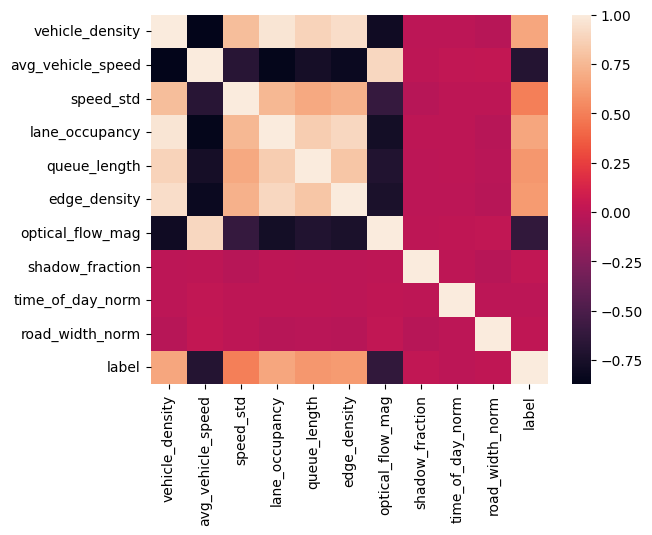

In [11]:
sns.heatmap(df.corr())

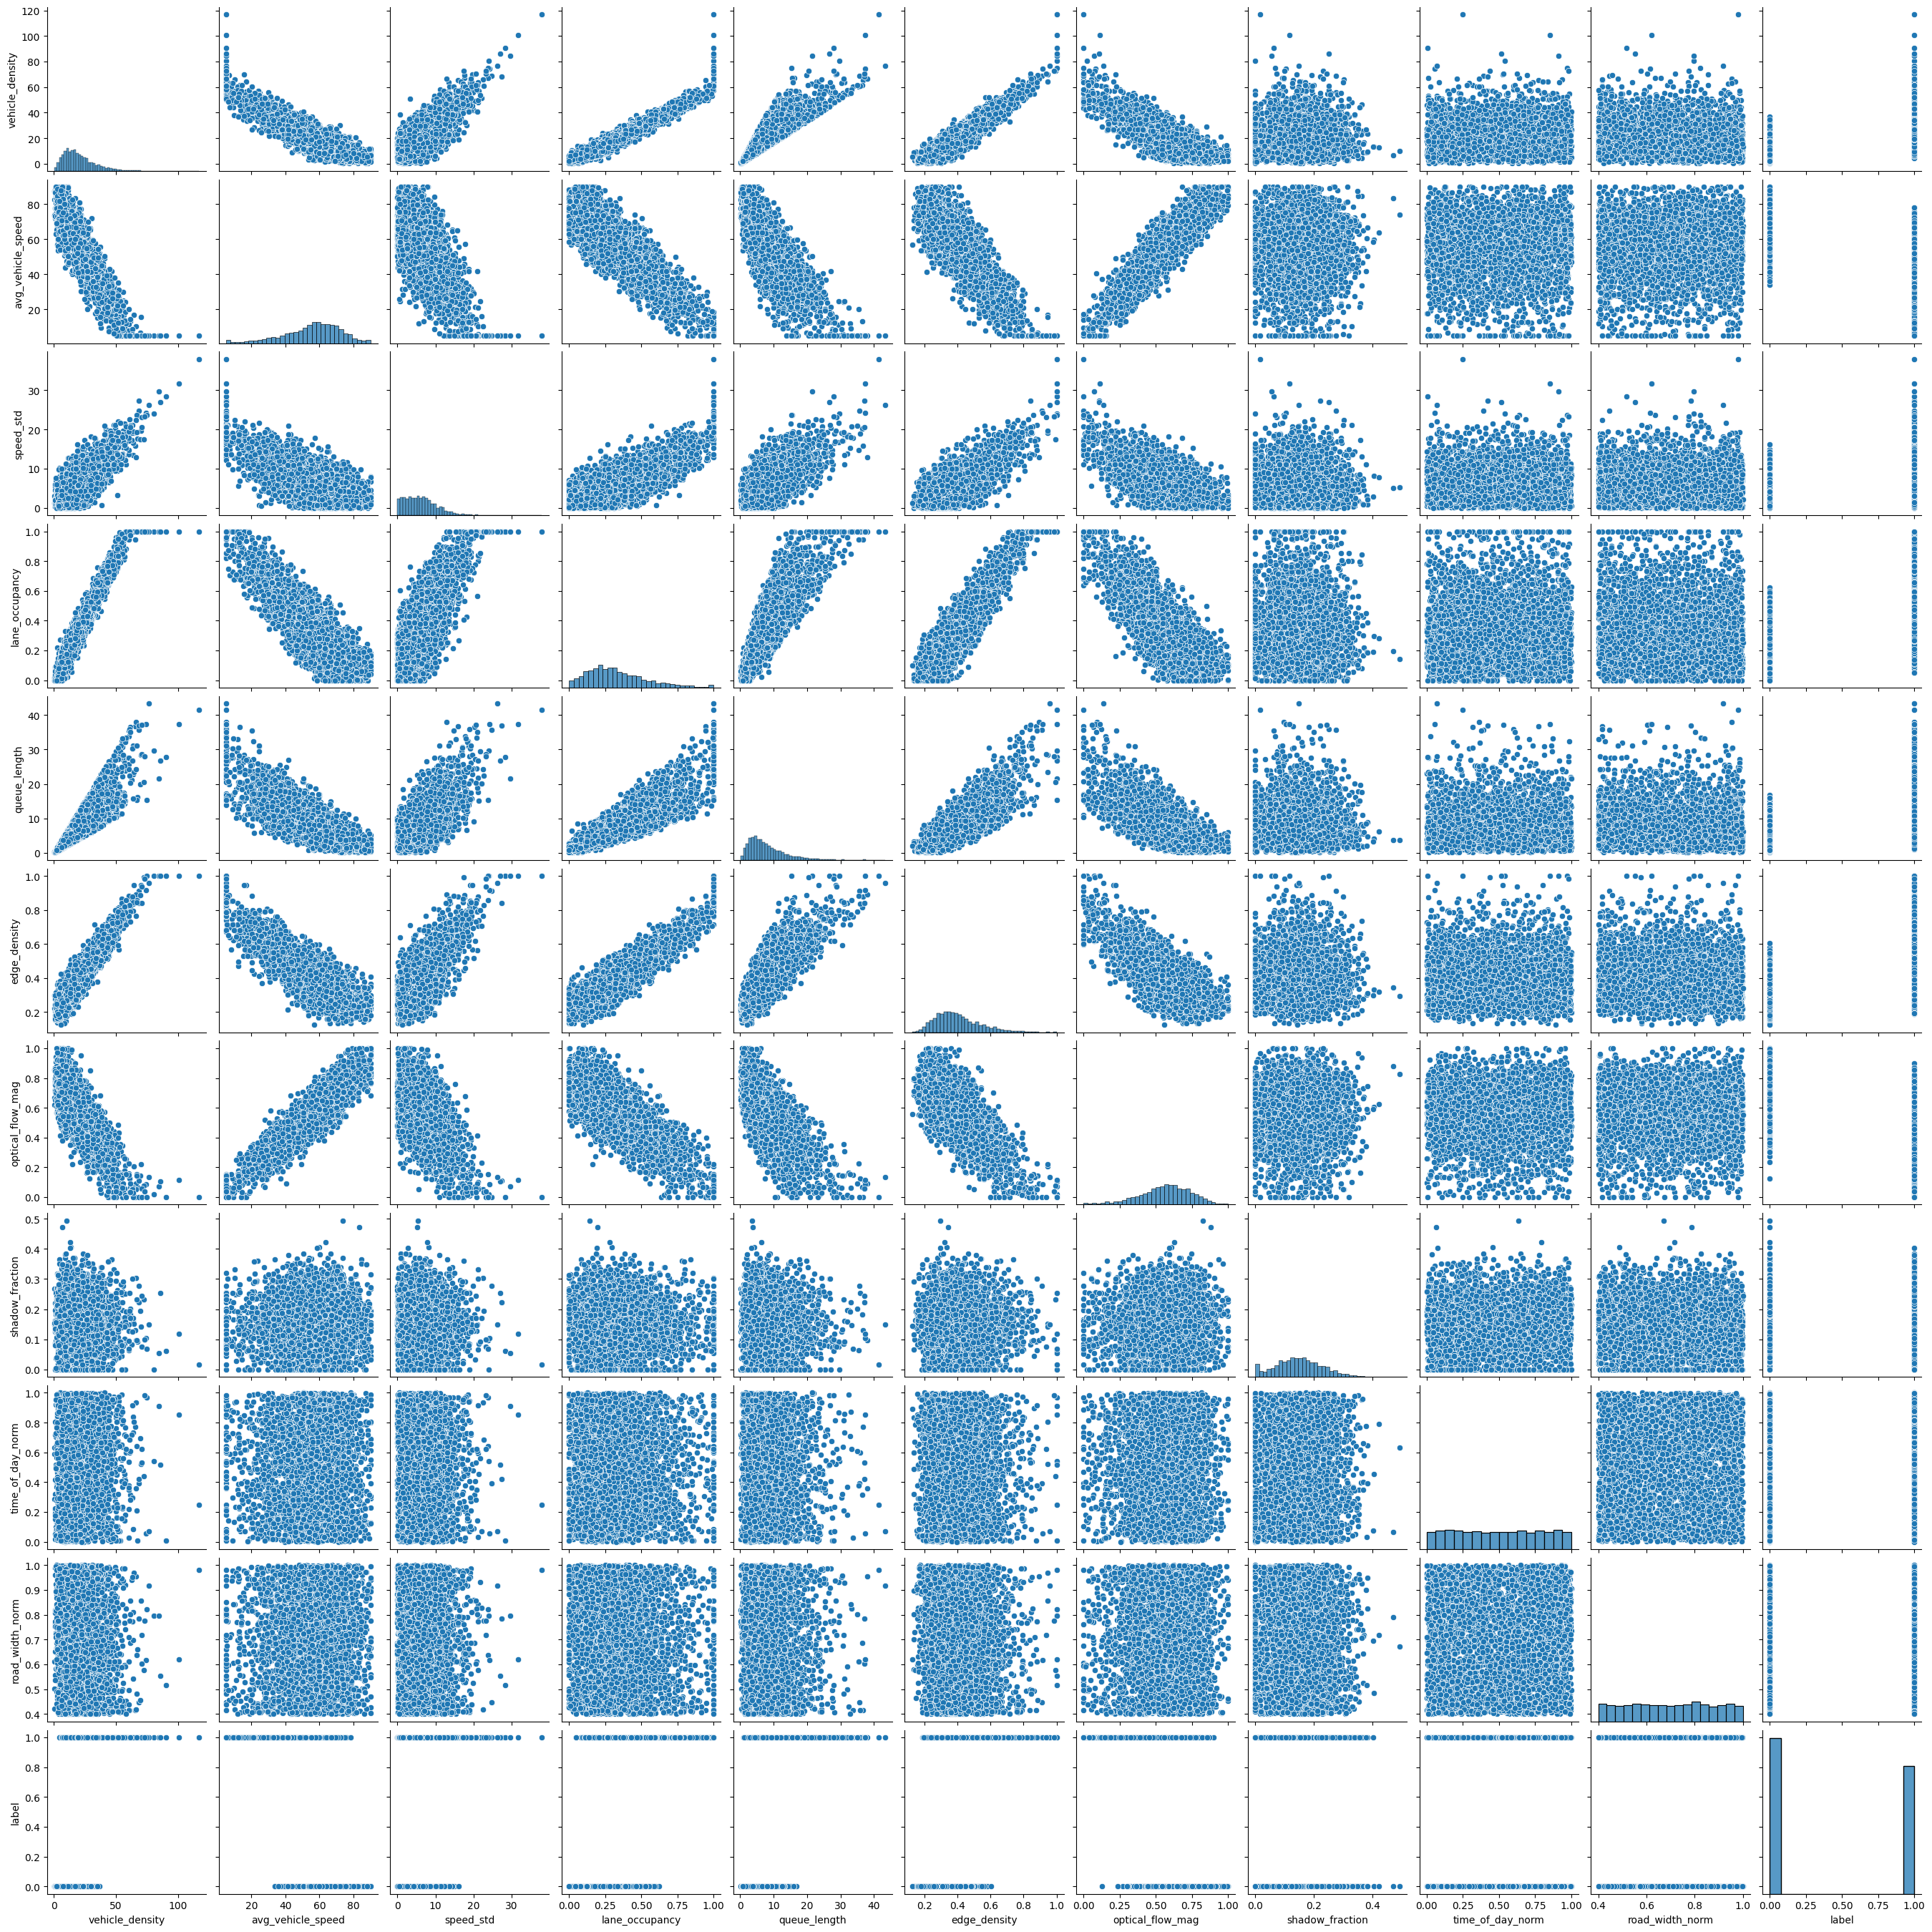

In [12]:
sns.pairplot(df)

# Task 1: Feature Description and Relevance

vehicle_density:  
Number of vehicles per unit road area.  
High density reduces space between vehicles and is a main cause of congestion.  

avg_vehicle_speed:  
Mean speed of vehicles in the tile.  
Congested traffic usually has low average speeds for extended periods.  

speed_std:  
Standard deviation of vehicle speeds.  
High variability shows stop-and-go traffic and unstable flow conditions.  

lane_occupancy:  
Fraction of lane space taken up by vehicles.  
High occupancy indicates road saturation and limited room to maneuver.  

queue_length:  
Estimated length of vehicle queues.  
This is a direct sign of congestion caused by bottlenecks or incidents.  

edge_density:  
Density of visual edges in aerial imagery.  
Serves as a visual indicator of vehicle presence and traffic clutter.  

optical_flow_mag:  
Magnitude of motion between consecutive frames.  
Low values suggest slow or stalled traffic, which is typical of congestion.  

shadow_fraction:  
Proportion of tile affected by shadows.  
This captures light effects to improve the reliability of image-based features.  

time_of_day_norm:  
Normalized time within a day.  
It provides context for peak and off-peak traffic patterns.  

road_width_norm:  
Normalized road width as a measure of capacity.  
Wider roads can handle higher traffic volumes before congestion starts.  

label:  
Binary target variable.  
0 = normal traffic, 1 = congestion or incident condition.  

In [13]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [14]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [15]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    objective='binary:logistic',
    random_state=42,
    n_jobs=-1,
    subsample=0.8,
    colsample_bytree=0.8
)
model = GridSearchCV(estimator=xgb_model, 
                     scoring='recall',
										 param_grid={'n_estimators': [200, 300, 400], 
																 'max_depth': [4,5,6], 
																 'learning_rate': [0.02, 0.03, 0.04, 0.05]
										 }, 
                     cv=3,
										 n_jobs=-1, 
										 verbose=2,
        )

In [16]:
model.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=200; total time=   0.3s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=300; total time=   0.3s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=300; total time=   0.3s
[CV] END ..learning_rate=0.02, max_depth=5, n_estimators=200; total time=   0.3s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=300; total time=   0.3s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=400; total time=   0.4s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=400; total time=   0.4s
[CV] END ..learning_rate=0.02, max_depth=4, n_estimators=400; total time=   0.4s
[CV] END ..learning_rate=0.02, max_depth=5, n_estimators=200; total time=   0.3s
[CV] END ..learning_rate=0.02, max_depth=5, n_e

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.02, 0.03, ...], 'max_depth': [4, 5, ...], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displaye

In [17]:
model = model.best_estimator_
model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       550
           1       0.82      0.81      0.81       450

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000

ROC-AUC: 0.9229252525252526
Confusion Matrix:
 [[468  82]
 [ 87 363]]


In [20]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

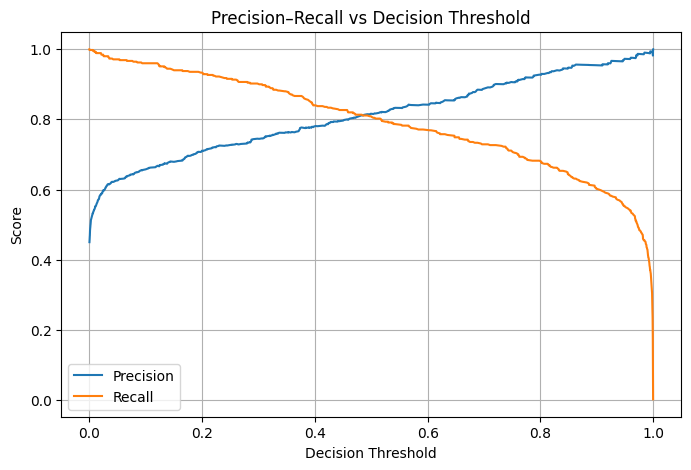

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
threshold = 0.25
y_pred_custom = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


[[396 154]
 [ 38 412]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80       550
           1       0.73      0.92      0.81       450

    accuracy                           0.81      1000
   macro avg       0.82      0.82      0.81      1000
weighted avg       0.83      0.81      0.81      1000



In [23]:
risk_band = np.where(
    y_prob >= 0.5, "HIGH",
    np.where(y_prob >= 0.25, "MEDIUM", "LOW")
)
risk_band

array(['LOW', 'LOW', 'HIGH', 'HIGH', 'HIGH', 'HIGH', 'LOW', 'HIGH', 'LOW',
       'LOW', 'LOW', 'HIGH', 'MEDIUM', 'LOW', 'LOW', 'LOW', 'HIGH',
       'MEDIUM', 'HIGH', 'HIGH', 'HIGH', 'LOW', 'MEDIUM', 'HIGH', 'HIGH',
       'LOW', 'HIGH', 'LOW', 'HIGH', 'HIGH', 'LOW', 'LOW', 'LOW', 'LOW',
       'LOW', 'LOW', 'HIGH', 'LOW', 'HIGH', 'HIGH', 'LOW', 'LOW', 'LOW',
       'LOW', 'HIGH', 'LOW', 'MEDIUM', 'HIGH', 'LOW', 'LOW', 'LOW', 'LOW',
       'HIGH', 'LOW', 'HIGH', 'LOW', 'MEDIUM', 'LOW', 'LOW', 'HIGH',
       'MEDIUM', 'HIGH', 'LOW', 'LOW', 'MEDIUM', 'HIGH', 'HIGH', 'HIGH',
       'LOW', 'LOW', 'HIGH', 'HIGH', 'LOW', 'HIGH', 'HIGH', 'HIGH', 'LOW',
       'HIGH', 'LOW', 'LOW', 'HIGH', 'LOW', 'HIGH', 'HIGH', 'HIGH', 'LOW',
       'HIGH', 'HIGH', 'HIGH', 'MEDIUM', 'HIGH', 'HIGH', 'HIGH', 'LOW',
       'LOW', 'HIGH', 'LOW', 'HIGH', 'LOW', 'LOW', 'MEDIUM', 'LOW', 'LOW',
       'MEDIUM', 'HIGH', 'LOW', 'MEDIUM', 'LOW', 'LOW', 'LOW', 'LOW',
       'LOW', 'MEDIUM', 'MEDIUM', 'MEDIUM', 'HIGH', '

In [24]:
model.save_model("traffic_model.json")
import json

metadata = {
    "threshold": 0.25,
    "features": list(X.columns),
    "risk_bands": {
        "low": "< 0.25",
        "medium": "0.25–0.5",
        "high": ">= 0.5"
    }
}

with open("traffic_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)


In [25]:
df_vis = X_test.copy()
df_vis["risk_score"] = y_prob
df_vis = df_vis.reset_index(drop=True)

grid_width = 25
df_vis["grid_x"] = df_vis.index % grid_width
df_vis["grid_y"] = df_vis.index // grid_width


In [26]:
df_vis.head()

,vehicle_density,avg_vehicle_speed,speed_std,lane_occupancy,queue_length,edge_density,optical_flow_mag,shadow_fraction,time_of_day_norm,road_width_norm,risk_score,grid_x,grid_y
0,11.025518,62.734819,3.550401,0.152853,6.379146,0.389979,0.626613,0.010776,0.030141,0.507490,0.229272,0,0
1,22.141148,64.753408,1.443303,0.453135,6.766278,0.489916,0.713856,0.202213,0.645243,0.686532,0.147184,1,0
2,33.685694,36.739552,11.545193,0.554257,17.995035,0.539666,0.348418,0.132803,0.236572,0.961801,0.999518,2,0
3,44.149373,25.989516,15.377914,0.687494,15.658859,0.628014,0.157591,0.109541,0.812900,0.680820,0.999632,3,0
4,26.933508,50.121780,5.522915,0.386231,10.463327,0.495696,0.491365,0.073684,0.552500,0.511619,0.675140,4,0


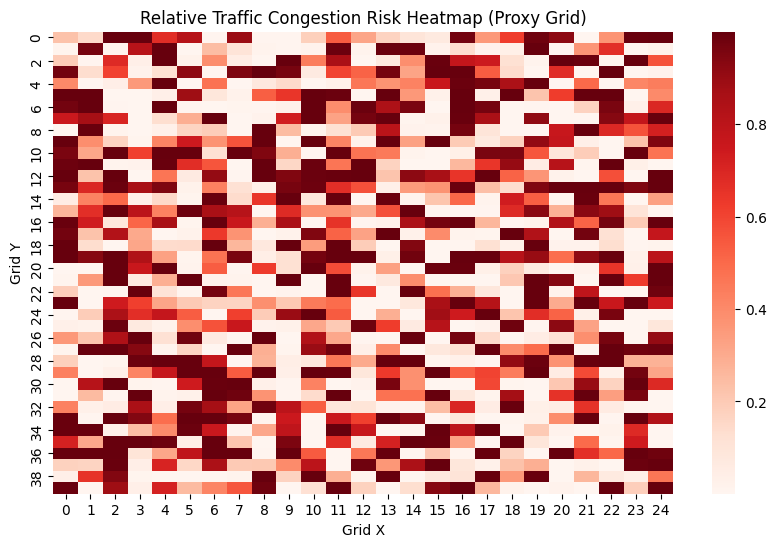

In [27]:
pivot = df_vis.pivot_table(
    values="risk_score",
    index="grid_y",
    columns="grid_x",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="Reds")
plt.title("Relative Traffic Congestion Risk Heatmap (Proxy Grid)")
plt.xlabel("Grid X")
plt.ylabel("Grid Y")
plt.show()


/Users/pernavjain/Documents/ML/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


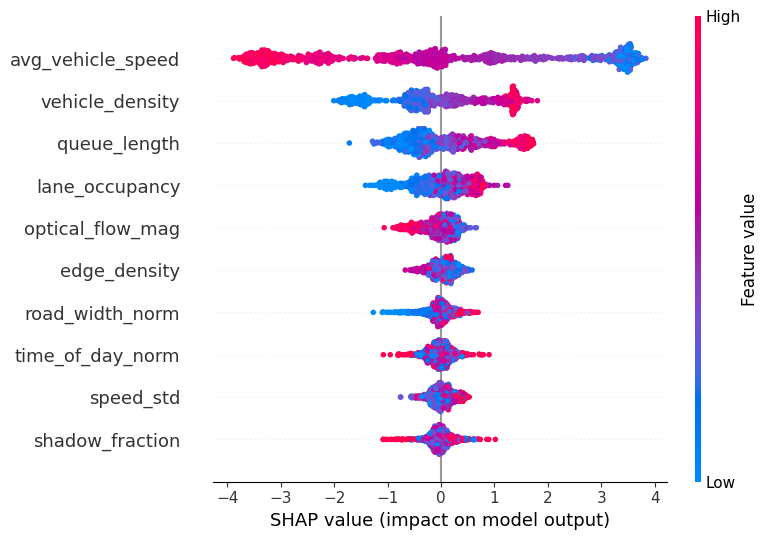

In [28]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


# Explanation of Spatial Visualization Results

1. Relative Traffic Congestion Risk Heatmap (Proxy Grid)

The spatial heatmap shows the predicted congestion risk scores gathered over a grid layout. Since the dataset does not provide specific geographic coordinates, grid indices help display the relative distribution of congestion risk across road segment tiles.

Each cell in the heatmap represents a tile, and the color intensity shows the predicted probability of congestion. Darker areas indicate a higher risk of congestion, while lighter areas signify lower risk.

The heatmap illustrates a varied risk distribution, with localized clusters of high congestion risk. These clusters suggest possible traffic bottlenecks or areas prone to incidents. The gradual changes in color intensity show that congestion severity varies in different areas rather than being uniform across all tiles.

This visualization helps identify high-risk regions that may need focused traffic management or monitoring efforts.

2. SHAP Summary Plot (Global Explainability)

The SHAP summary plot displays how each feature contributes to the model’s congestion risk predictions. Features are arranged by their overall importance, based on the magnitude of SHAP values.

Positive SHAP values show an increase in predicted congestion risk, while negative values indicate a decrease. The color gradient indicates feature values, with higher values in red and lower values in blue.

The plot reveals that average vehicle speed has the strongest effect on the model’s output, with lower speeds significantly raising congestion risk. Vehicle density, queue length, and lane occupancy also add to congestion predictions when their values are high. Motion-based features, like optical flow magnitude, help reduce congestion risk when movement is high.

Contextual and environmental features such as road width, time of day, speed variability, and shadow fraction have a lesser influence but still help refine predictions when combined with key traffic flow indicators.

# Proposed Traffic Management and Emergency Response Actions


1. Priority-Based Congestion Monitoring

The model shows high recall (0.92) for detecting congestion. This means it effectively identifies most congestion or incident events. We can use model outputs as an early-warning system to prioritize monitoring high-risk road segments. 

Road tiles marked with high congestion risk should be continuously monitored through traffic control centers to allow for timely intervention.

2. Targeted Intervention in High-Risk Zones

Spatial heatmap analysis reveals clusters of high congestion risk. We can treat these areas as priority zones for traffic management actions such as:

- Adjusting dynamic traffic signal timing
- Temporarily reallocating lanes
- Deploying traffic personnel during peak risk periods

This focused approach helps make the best use of limited traffic management resources.

3. Incident Detection and Emergency Dispatch

The low false-negative rate (38 missed cases out of 450 congestion instances) shows reliable incident detection. High-risk predictions can prompt quick verification through CCTV or aerial surveillance.

Confirmed incidents can lead to immediate emergency response actions like:

- Dispatching traffic police or tow services
- Clearing stalled or accident-involved vehicles
- Temporarily rerouting traffic flow

4. Preventive Traffic Control Measures

Model explainability results indicate that congestion risk mainly comes from high vehicle density, long queue lengths, high lane occupancy, and slower average speeds. Preventive measures might include:

- Sending advance congestion alerts to traffic operators
- Proactively diverting traffic when density limits are reached
- Using adaptive control strategies to lessen queue buildup before full congestion happens

5. Dynamic Risk-Based Decision Support

The model’s probabilistic output allows us to categorize congestion risk into different severity levels. Traffic authorities can use these levels to apply varying response strategies, where:

- Medium-risk areas are closely monitored
- High-risk areas receive immediate intervention

This supports a traffic management approach that considers risk instead of just making binary decisions.

6. Support for Long-Term Infrastructure Planning

Repeatedly identifying high-risk spatial clusters over time can guide long-term planning decisions, such as:

- Widening roads
- Redesigning signals
- Increasing capacity at recurrent bottlenecks

Thus, model outputs can aid both operational and strategic traffic management goals.

# Limitations and Future Improvements

1. Limitations

The dataset does not contain explicit geographic coordinates; therefore, spatial heatmaps represent relative risk distribution using a proxy grid rather than true road locations.

The model relies on pre-extracted traffic features and does not directly process raw aerial imagery, making performance dependent on feature extraction quality.

Congestion is treated as a binary classification problem, which does not capture different levels or types of congestion severity.

Temporal dependencies between consecutive traffic states are not modeled, limiting the system’s ability to capture congestion evolution over time.

The model prioritizes high recall, resulting in a moderate number of false positives that may require human verification.

2. Future Improvements

Incorporating geographic coordinates and road network topology would enable accurate geospatial visualization and network-level analysis.

Temporal modeling using sequential data can improve early detection of congestion buildup and dissipation.

Extending the model to multi-class or severity-based prediction would support finer traffic management decisions.

End-to-end learning from raw aerial imagery could reduce reliance on handcrafted features and improve robustness.

Adaptive thresholding and integration with real-time traffic systems would enhance operational deployment and decision support.